# 02 - K-Means Clustering
Cluster music genres based on streaming features using K-Means algorithm.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
# Load dataset
df = pd.read_csv('../data/spotify_final_cleaned.csv')

# Feature engineering
cluster_data = df.groupby('Genre').agg({
    'Streams': 'mean',
    'Position': 'mean',
    'Track Name': 'count',
    'Weeks on Chart': 'mean'
}).reset_index()

cluster_data.columns = [
    'Genre',
    'Avg_Streams',
    'Avg_Position',
    'Song_Count',
    'Avg_Weeks_On_Chart'
]

print(cluster_data)

           Genre   Avg_Streams  Avg_Position  Song_Count  Avg_Weeks_On_Chart
0      Afrobeats  1.231372e+07    107.863636          22           27.590909
1      Bollywood  1.147345e+07    116.629630          27            8.666667
2    Classic Pop  1.794693e+07     96.305556         288           35.857639
3        Country  1.327854e+07    100.965116          86           30.220930
4   Desi Hip-Hop  1.863466e+07     69.333333           3            9.333333
5       Desi Pop  9.724546e+06    133.600000           5            4.400000
6     Electronic  1.113319e+07    120.868966         145           89.255172
7       Folk/Pop  1.458490e+07     89.292818         181          118.933702
8        Hip-Hop  1.377896e+07    104.266003         703           63.968706
9          Indie  1.500217e+07     88.333333          72           50.083333
10     Indie Pop  1.348252e+07    101.224299         321           54.467290
11    Indie Rock  1.286122e+07     93.409091          88          116.238636

In [3]:
# Scaling
features = cluster_data[[
    'Avg_Streams',
    'Avg_Position',
    'Song_Count',
    'Avg_Weeks_On_Chart'
]]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

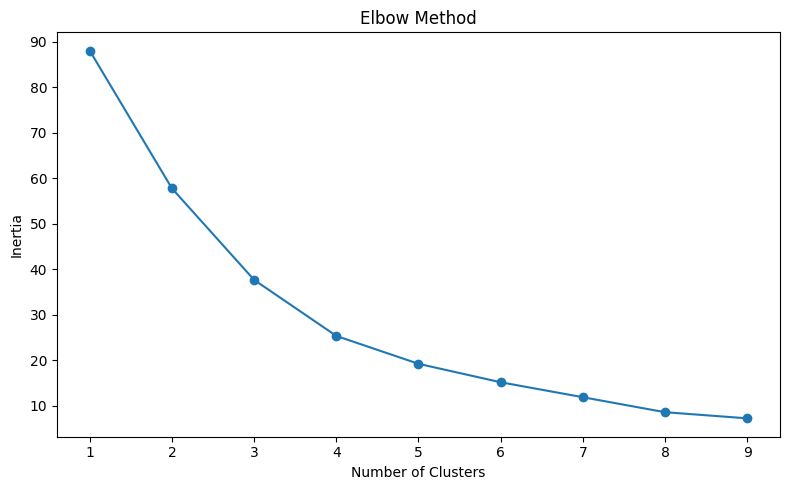

In [4]:
# Elbow method
import os
os.makedirs('../outputs', exist_ok=True)

inertia = []

K = range(1, 10)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

plt.tight_layout()
plt.savefig('../outputs/elbow_method.png')
plt.show()

In [5]:
# K-Means clustering
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_data['Cluster'] = kmeans.fit_predict(
    scaled_features
)

# Silhouette score
score = silhouette_score(
    scaled_features,
    cluster_data['Cluster']
)

print('Silhouette Score:', score)

print(cluster_data)

Silhouette Score: 0.3471464388360397
           Genre   Avg_Streams  Avg_Position  Song_Count  Avg_Weeks_On_Chart  \
0      Afrobeats  1.231372e+07    107.863636          22           27.590909   
1      Bollywood  1.147345e+07    116.629630          27            8.666667   
2    Classic Pop  1.794693e+07     96.305556         288           35.857639   
3        Country  1.327854e+07    100.965116          86           30.220930   
4   Desi Hip-Hop  1.863466e+07     69.333333           3            9.333333   
5       Desi Pop  9.724546e+06    133.600000           5            4.400000   
6     Electronic  1.113319e+07    120.868966         145           89.255172   
7       Folk/Pop  1.458490e+07     89.292818         181          118.933702   
8        Hip-Hop  1.377896e+07    104.266003         703           63.968706   
9          Indie  1.500217e+07     88.333333          72           50.083333   
10     Indie Pop  1.348252e+07    101.224299         321           54.467290   
11 

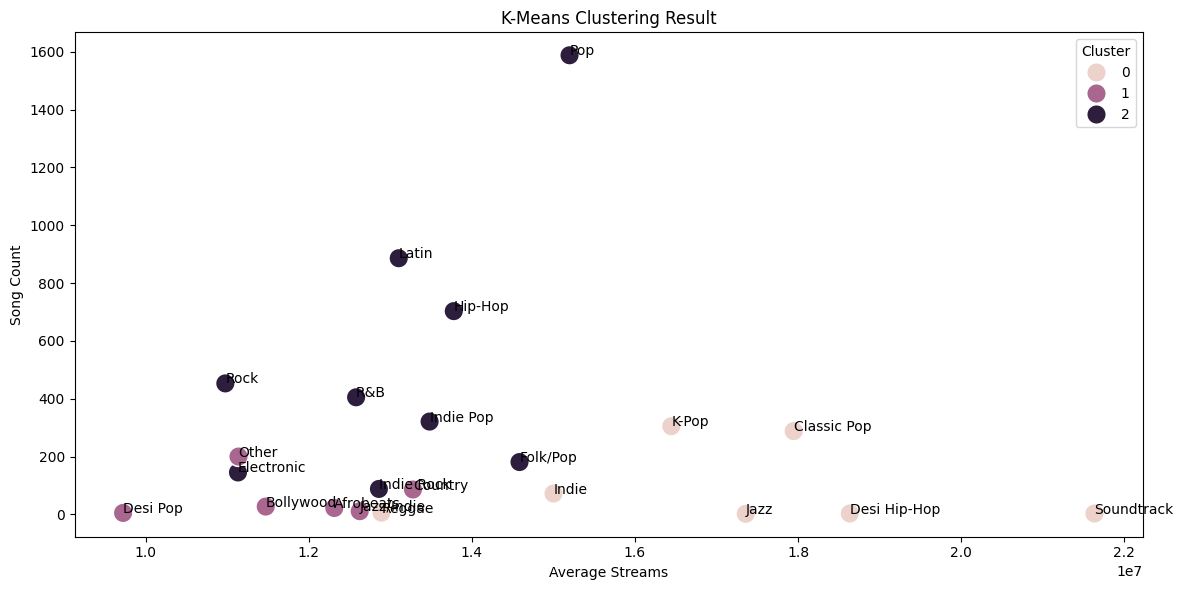

In [6]:
# Visualization
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=cluster_data,
    x='Avg_Streams',
    y='Song_Count',
    hue='Cluster',
    s=200
)

for i in range(len(cluster_data)):
    plt.text(
        cluster_data['Avg_Streams'].iloc[i],
        cluster_data['Song_Count'].iloc[i],
        cluster_data['Genre'].iloc[i]
    )

plt.title('K-Means Clustering Result')
plt.xlabel('Average Streams')
plt.ylabel('Song Count')

plt.tight_layout()
plt.savefig('../outputs/clustering_result.png')
plt.show()